Path: A -> B -> E -> F

Best First Search Table:

  Visited Node  Heuristic Value
0            A                5
1            B                3
2            E                1
3            F                0


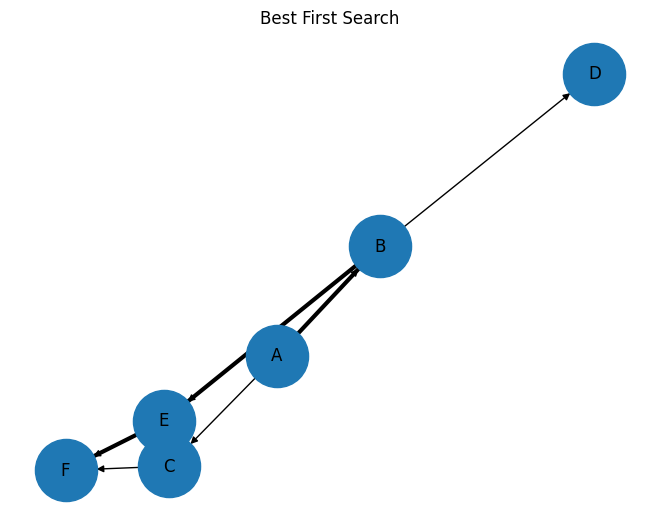

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Graph
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [], 'E': ['F'], 'F': []
}

# Heuristic values
h = {'A':5, 'B':3, 'C':4, 'D':2, 'E':1, 'F':0}

# Best First Search
def best_first(start, goal):
    open_list = [start]
    visited = []
    parent = {start: None}

    while open_list:
        node = min(open_list, key=lambda x: h[x])
        open_list.remove(node)

        if node == goal:
            path = []
            while node:
                path.append(node)
                node = parent[node]
            return path[::-1], visited

        visited.append(node)

        for n in graph[node]:
            if n not in visited and n not in open_list:
                parent[n] = node
                open_list.append(n)

# Run
result, visited = best_first('A', 'F')

print("Path:", " -> ".join(result))

# Table Output
table = pd.DataFrame({
    "Visited Node": visited + [result[-1]],
    "Heuristic Value": [h[i] for i in visited + [result[-1]]]
})

print("\nBest First Search Table:\n")
print(table)

# Draw Graph
G = nx.DiGraph()

for u in graph:
    for v in graph[u]:
        G.add_edge(u, v)

pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=2000)

# Highlight path
path_edges = [(result[i], result[i+1]) for i in range(len(result)-1)]
nx.draw_networkx_edges(G, pos, edgelist=path_edges, width=3)

plt.title("Best First Search")
plt.show()